In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read Data

In [25]:
df = pd.read_csv("dataset/20160930_203718.csv")

In [26]:
df.head()

,Time (s),CO (ppm),Humidity (%r.h.),Temperature (C),Flow rate (mL/min),Heater voltage (V),R1 (MOhm),R2 (MOhm),R3 (MOhm),R4 (MOhm),R5 (MOhm),R6 (MOhm),R7 (MOhm),R8 (MOhm),R9 (MOhm),R10 (MOhm),R11 (MOhm),R12 (MOhm),R13 (MOhm),R14 (MOhm)
0,0.000,0.0,49.7534,23.7184,233.2737,0.8993,0.2231,0.6365,1.1493,0.8483,1.2534,1.4449,1.9906,1.3303,1.4480,1.9148,3.4651,5.2144,6.5806,8.6385
1,0.309,0.0,55.8400,26.6200,241.6323,0.2112,2.1314,5.3552,9.7569,6.3188,9.4472,10.5769,13.6317,21.9829,16.1902,24.2780,31.1014,34.7193,31.7505,41.9167
2,0.618,0.0,55.8400,26.6200,241.3888,0.2070,10.5318,22.5612,37.2635,17.7848,33.0704,36.3160,42.5746,49.7495,31.7533,57.7289,53.6275,56.9212,47.8255,62.9436
3,0.926,0.0,55.8400,26.6200,241.1461,0.2042,29.5749,49.5111,65.6318,26.1447,58.3847,67.5130,68.0064,59.2824,36.7821,66.0832,66.8349,66.9695,50.3730,64.8363
4,1.234,0.0,55.8400,26.6200,240.9121,0.2030,49.5111,67.0368,77.8317,27.9625,71.7732,79.9474,79.8631,62.5385,39.6271,68.1441,62.0947,49.4614,52.8453,66.8445


# Explore

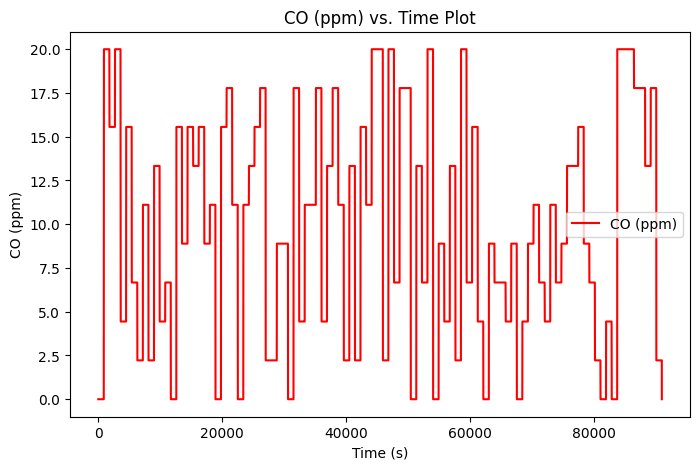

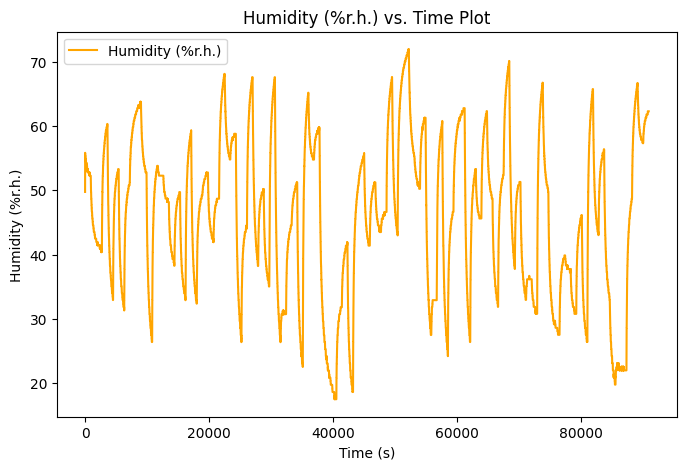

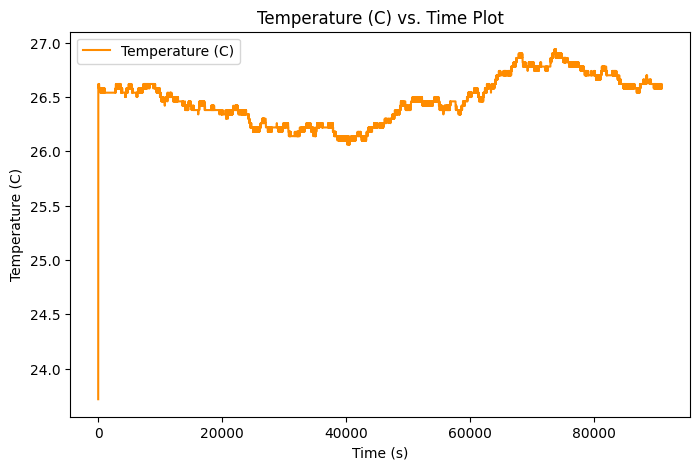

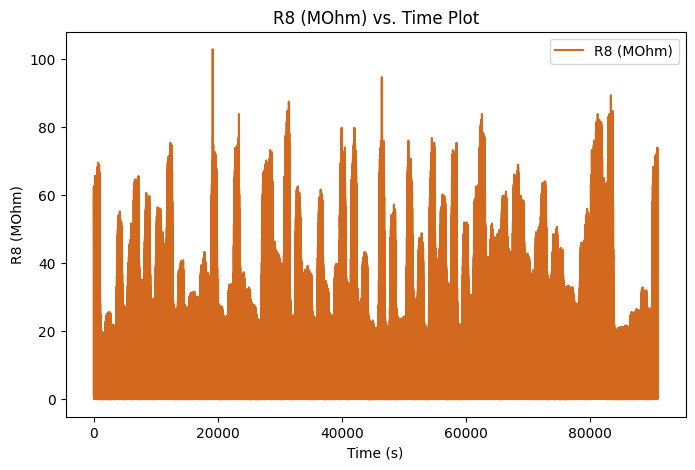

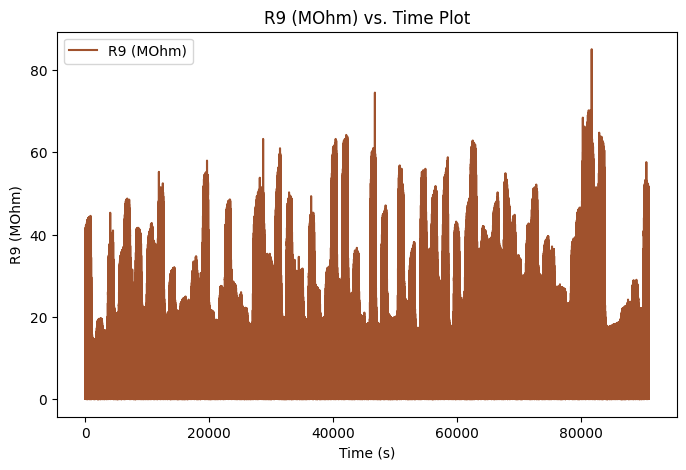

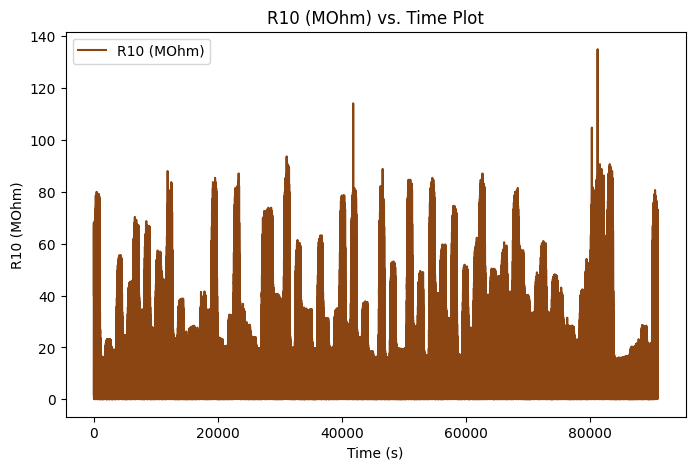

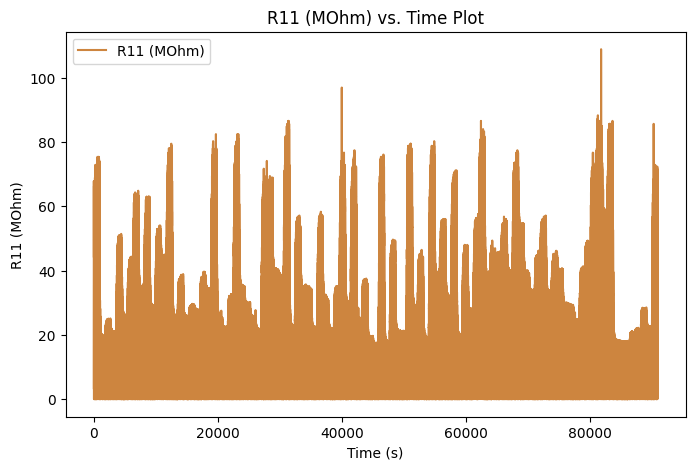

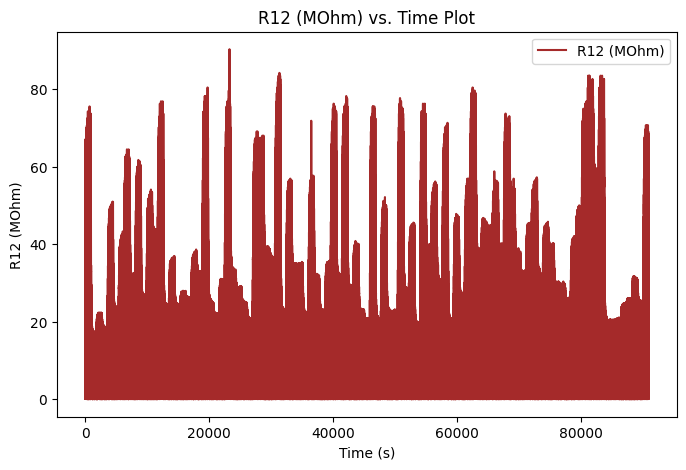

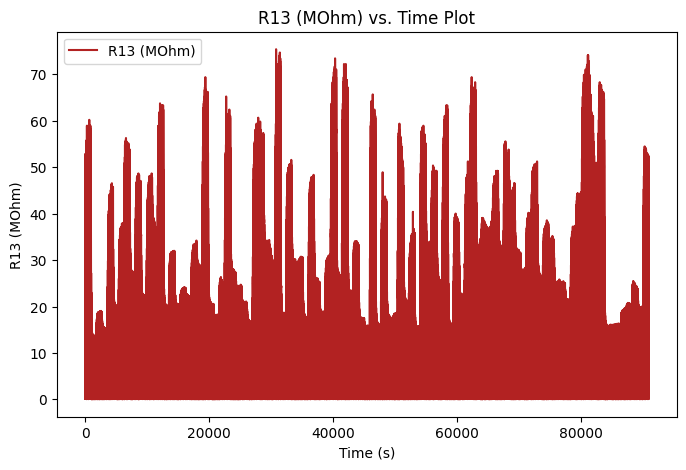

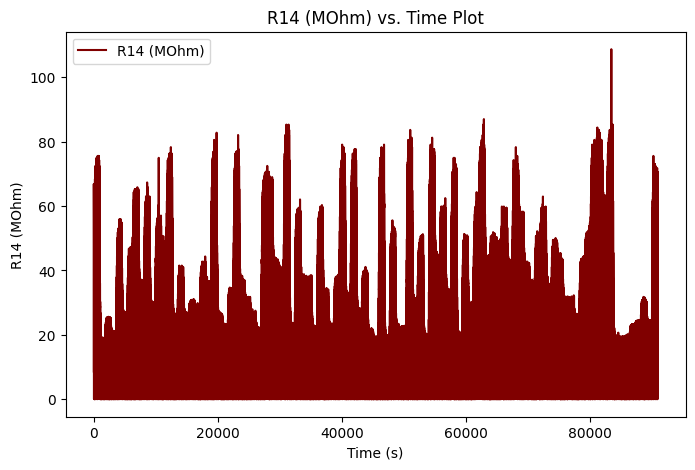

In [27]:
# Specify the columns you want to plot (excluding 'Time (s)')
columns_to_plot = ['CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)', 'R8 (MOhm)',
                   'R9 (MOhm)', 'R10 (MOhm)', 'R11 (MOhm)', 'R12 (MOhm)', 'R13 (MOhm)',
                   'R14 (MOhm)']

# Define a list of warm colors
warm_colors = ['red', 'orange', 'darkorange', 'chocolate', 'sienna',
               'saddlebrown', 'peru', 'brown', 'firebrick', 'maroon']

# Plot each column with a warm color
for i, column in enumerate(columns_to_plot):
    plt.figure(figsize=(8, 5))
    plt.plot(df['Time (s)'], df[column], label=column, color=warm_colors[i])
    plt.xlabel('Time (s)')
    plt.ylabel(column)
    plt.title(f'{column} vs. Time Plot')
    plt.legend()
    plt.show()


# CDF Temperature

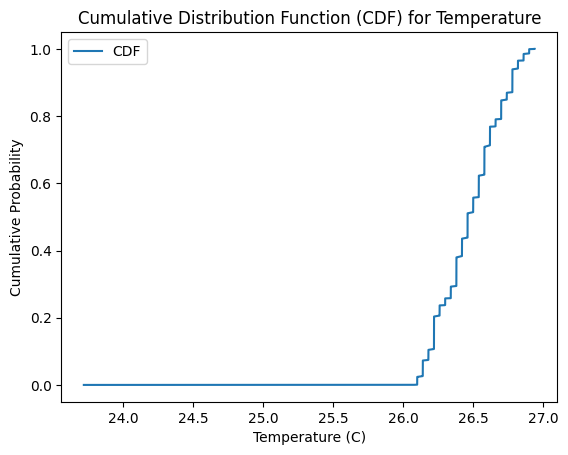

In [28]:
# Extract the 'Temperature (C)' column from the DataFrame
temperature_data = df['Temperature (C)']

# Sort the data in ascending order
sorted_temperature = np.sort(temperature_data)

# Calculate the CDF
cdf_temperature = np.arange(1, len(sorted_temperature) + 1) / len(sorted_temperature)

# Plot the CDF for 'Temperature (C)'
plt.plot(sorted_temperature, cdf_temperature, label='CDF')

# Add labels and title
plt.xlabel('Temperature (C)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF) for Temperature')

# Show legend
plt.legend()

# Display the plot
plt.show()

# Correlation

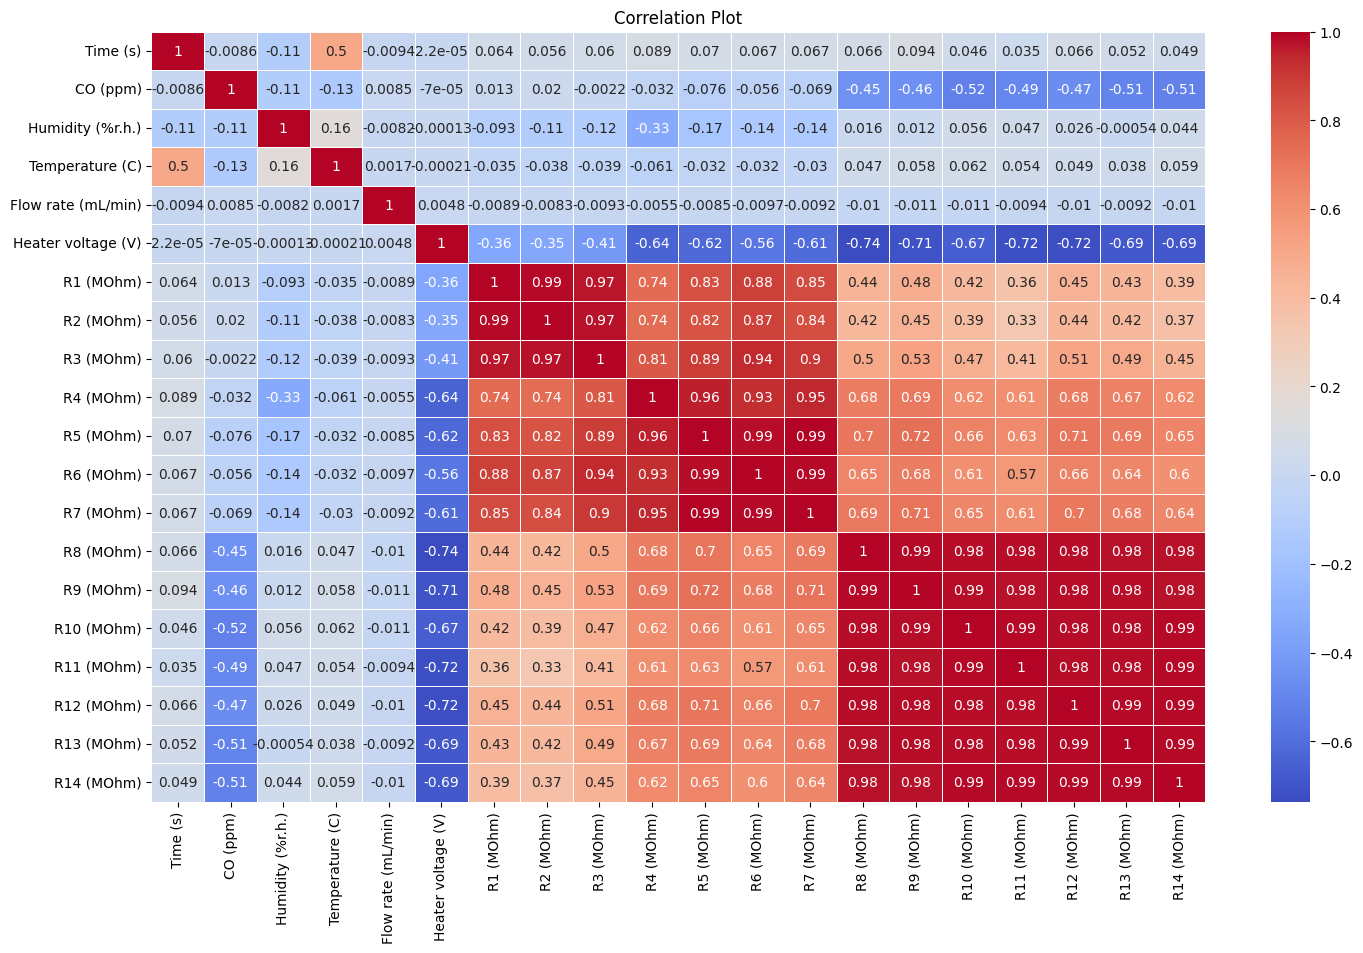

In [29]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(17, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Plot')
plt.show()

# Correlation for CO

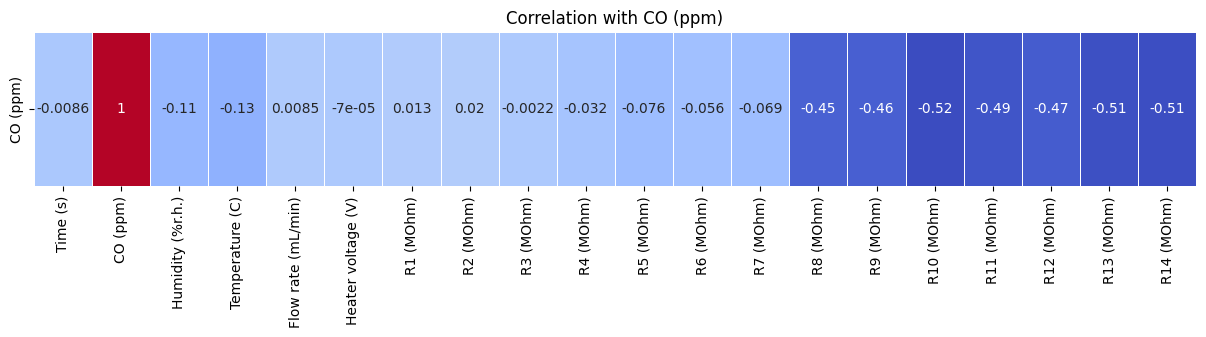

In [30]:
specific_column = 'CO (ppm)'  

# Calculate correlation matrix for the specific column
column_correlation = df.corrwith(df[specific_column])

# Create a heatmap using Seaborn for visualization
plt.figure(figsize=(15, 2))
sns.heatmap(pd.DataFrame(column_correlation, columns=[specific_column]).T,
            annot=True, cmap='coolwarm', linewidths=.5, cbar=False)
plt.title(f'Correlation with {specific_column}')
plt.show()

# Remove columns with low correlation

In [31]:
absolute_correlation_threshold = 0.1  # Adjust as needed

# Calculate correlation with the specific column
column_correlation = df.corr().abs()[specific_column]

# Find columns with correlation below the absolute threshold
low_correlation_cols = column_correlation[column_correlation < absolute_correlation_threshold].index

if 'Time (s)' in low_correlation_cols:
    low_correlation_cols = low_correlation_cols.drop('Time (s)')

# Drop columns with low correlation
df_filtered = df.drop(low_correlation_cols, axis=1)

# Display the filtered DataFrame
print(df_filtered.columns)

Index(['Time (s)', 'CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)',
       'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)', 'R11 (MOhm)', 'R12 (MOhm)',
       'R13 (MOhm)', 'R14 (MOhm)'],
      dtype='object')


In [9]:
df_filtered.head()

,Time (s),CO (ppm),R5 (MOhm),R8 (MOhm),R9 (MOhm),R10 (MOhm),R11 (MOhm),R12 (MOhm),R13 (MOhm),R14 (MOhm)
0,0.000,0.0,1.2534,1.3303,1.4480,1.9148,3.4651,5.2144,6.5806,8.6385
1,0.309,0.0,9.4472,21.9829,16.1902,24.2780,31.1014,34.7193,31.7505,41.9167
2,0.618,0.0,33.0704,49.7495,31.7533,57.7289,53.6275,56.9212,47.8255,62.9436
3,0.926,0.0,58.3847,59.2824,36.7821,66.0832,66.8349,66.9695,50.3730,64.8363
4,1.234,0.0,71.7732,62.5385,39.6271,68.1441,62.0947,49.4614,52.8453,66.8445


# Outliers

In [48]:
# Specify the columns for which you want to find outliers
columns_to_check = ['CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)',
                    'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)',
                    'R11 (MOhm)', 'R12 (MOhm)', 'R13 (MOhm)', 'R14 (MOhm)']

# Set a z-score threshold for identifying outliers
z_score_threshold = 4  # Adjust as needed

# Create a DataFrame to store outliers and their z-scores
outliers_df = pd.DataFrame(columns=['Column', 'Outliers', 'Z-Scores'])

# Iterate through each column
for column_to_check in columns_to_check:
    # Calculate z-scores for the current column
    z_scores = stats.zscore(df_filtered[column_to_check])

    # Find indices of outliers
    outlier_indices = abs(z_scores) > z_score_threshold

    # Get the actual values and z-scores of outliers
    outliers = df_filtered.loc[outlier_indices, column_to_check]
    outlier_z_scores = z_scores[outlier_indices]

    # Add data to the outliers_df DataFrame
    column_outliers_df = pd.DataFrame({
        'Column': [column_to_check] * len(outliers),
        'Outliers': outliers.values,
        'Z-Scores': outlier_z_scores
    })
    outliers_df = pd.concat([outliers_df, column_outliers_df], ignore_index=True)

# Display the DataFrame with outliers and z-scores
outliers_df.sort_values(by=['Z-Scores'])

/tmp/ipykernel_1994983/3065510673.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outliers_df = pd.concat([outliers_df, column_outliers_df], ignore_index=True)


,Column,Outliers,Z-Scores
0,Temperature (C),23.7184,-13.031041


# Handling Outliers

In [50]:
# Specify the columns for which you want to find outliers
columns_to_check = ['CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)',
                    'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)',
                    'R11 (MOhm)', 'R12 (MOhm)', 'R13 (MOhm)', 'R14 (MOhm)']

# Set a z-score threshold for identifying outliers
z_score_threshold = 4  # Adjust as needed

# Create a copy of the DataFrame to avoid modifying the original
df_cleaned = df_filtered.copy()

# Iterate through each column
for column_to_check in columns_to_check:
    # Calculate z-scores for the current column
    z_scores = stats.zscore(df_cleaned[column_to_check])

    # Find indices of outliers
    outlier_indices = abs(z_scores) > z_score_threshold

    # Replace values with the mean of the next and previous data points (considering only non-null values)
    for idx in df_cleaned.index[outlier_indices]:
        if idx - 1 in df_cleaned.index and idx + 1 in df_cleaned.index:
            previous_value = df_cleaned.at[idx - 1, column_to_check]
            next_value = df_cleaned.at[idx + 1, column_to_check]

            # Consider only non-null values for calculating the mean
            if pd.notnull(previous_value) and pd.notnull(next_value):
                mean_value = (previous_value + next_value) / 2
                df_cleaned.at[idx, column_to_check] = mean_value

#df_cleaned['Temperature (C)'] = np.where(df_cleaned['Temperature (C)'] < 25.9, df_cleaned['Temperature (C)'].mean(), df_cleaned['Temperature (C)'])
# Display the cleaned DataFrame
df_cleaned.head()

,Time (s),CO (ppm),Humidity (%r.h.),Temperature (C),R8 (MOhm),R9 (MOhm),R10 (MOhm),R11 (MOhm),R12 (MOhm),R13 (MOhm),...,R12 (MOhm) Mean,R12 (MOhm)_Median,R12 (MOhm)_Std,R13 (MOhm) Mean,R13 (MOhm)_Median,R13 (MOhm)_Std,R14 (MOhm) Mean,R14 (MOhm)_Median,R14 (MOhm)_Std,Time (s)_Rate_of_Change
0,0.000,0.0,49.7534,23.7184,1.3303,1.4480,1.9148,3.4651,5.2144,6.5806,...,5.214400,5.21440,20.863115,6.580600,6.58060,17.797807,8.638500,8.63850,23.531241,1.0
1,0.309,0.0,55.8400,26.6200,21.9829,16.1902,24.2780,31.1014,34.7193,31.7505,...,19.966850,19.96685,20.863115,19.165550,19.16555,17.797807,25.277600,25.27760,23.531241,1.0
2,0.618,0.0,55.8400,26.6200,49.7495,31.7533,57.7289,53.6275,56.9212,47.8255,...,32.284967,34.71930,25.939213,28.718867,31.75050,20.788904,37.832933,41.91670,27.381907,1.0
3,0.926,0.0,55.8400,26.6200,59.2824,36.7821,66.0832,66.8349,66.9695,50.3730,...,40.956100,45.82025,27.373638,34.132400,39.78800,20.133167,44.583775,52.43015,26.117836,1.0
4,1.234,0.0,55.8400,26.6200,62.5385,39.6271,68.1441,62.0947,49.4614,52.8453,...,42.657160,49.46140,24.009479,37.874980,47.82550,19.340187,49.035920,62.94360,24.712628,1.0


# CDF after handling outliers

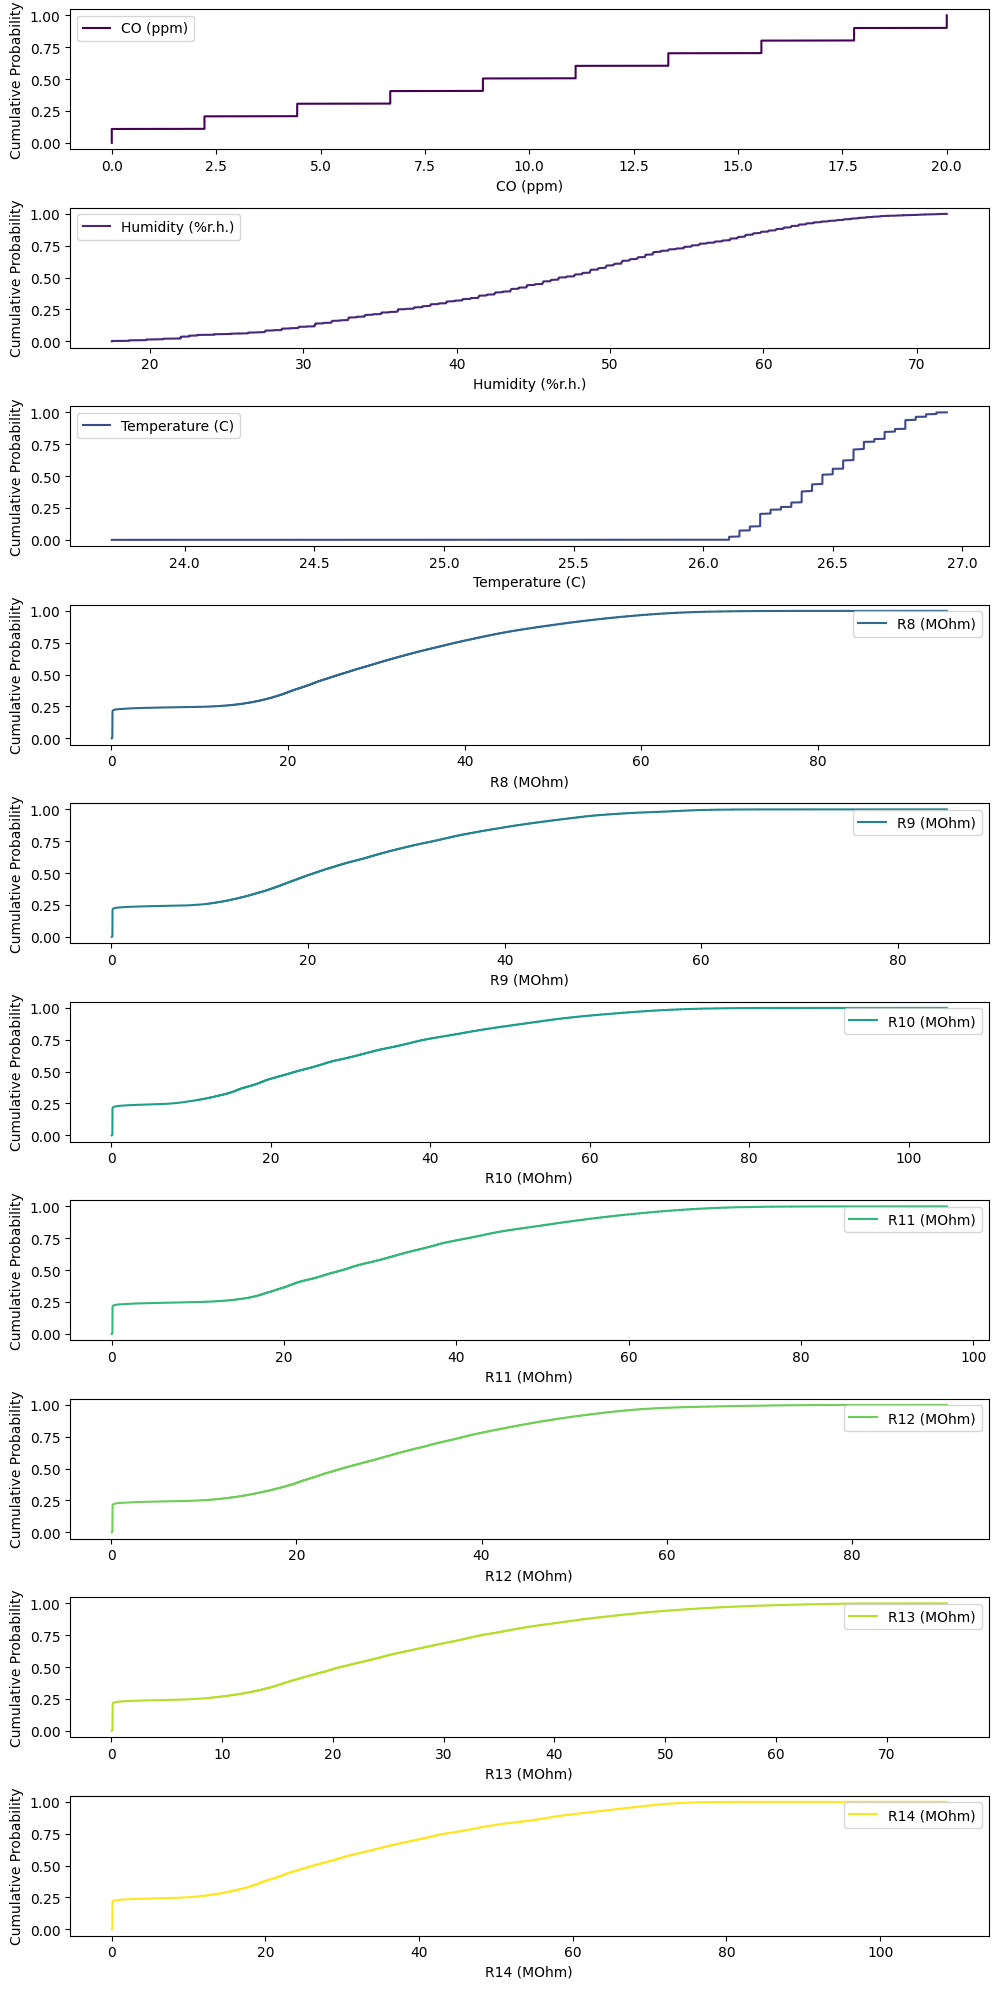

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Assuming 'df_cleaned' is your DataFrame
# If not, replace 'df_cleaned' with your actual DataFrame variable name

# Specify the columns for which you want to draw CDF plots
columns_to_check = ['CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)',
                    'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)',
                    'R11 (MOhm)', 'R12 (MOhm)', 'R13 (MOhm)', 'R14 (MOhm)']

# Set up subplots for multiple CDF plots
fig, axs = plt.subplots(len(columns_to_check), 1, figsize=(10, 2 * len(columns_to_check)))

# Define a color map for different colors
colors = plt.cm.viridis(np.linspace(0, 1, len(columns_to_check)))

# Loop through each column and plot the CDF with a different color
for i, (column, color) in enumerate(zip(columns_to_check, colors)):
    # Extract the column data
    column_data = df_cleaned[column]

    # Sort the data in ascending order
    sorted_data = np.sort(column_data)

    # Calculate the CDF
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

    # Plot the CDF for the current column with a different color
    axs[i].plot(sorted_data, cdf, label=column, color=color)

    # Add labels and title
    axs[i].set_xlabel(column)
    axs[i].set_ylabel('Cumulative Probability')
    axs[i].legend()

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


# Clustering Target

## Elbow

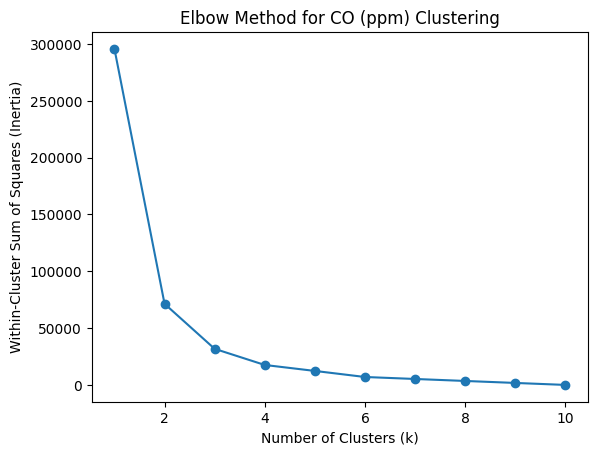

In [52]:
# Extract the 'CO (ppm)' column data
co_data = df_cleaned[['CO (ppm)']]

# Standardize the data (important for KMeans)
scaler = StandardScaler()
co_data_scaled = scaler.fit_transform(co_data)

# Use the elbow method to find the optimal number of clusters
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(co_data_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Method for CO (ppm) Clustering')
plt.show()


# Clustered Target

In [53]:
# Extract the 'CO (ppm)' column data
co_data = df_cleaned[['CO (ppm)']]

# Standardize the data (important for KMeans)
scaler = StandardScaler()
co_data_scaled = scaler.fit_transform(co_data)

# Use KMeans with the optimal number of clusters (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=5)
df_cleaned['Clustered_Target'] = kmeans.fit_predict(co_data_scaled)

# Display the DataFrame with the new 'Clustered_Target' column
df_cleaned.head(100)

,Time (s),CO (ppm),Humidity (%r.h.),Temperature (C),R8 (MOhm),R9 (MOhm),R10 (MOhm),R11 (MOhm),R12 (MOhm),R13 (MOhm),...,R12 (MOhm) Mean,R12 (MOhm)_Median,R12 (MOhm)_Std,R13 (MOhm) Mean,R13 (MOhm)_Median,R13 (MOhm)_Std,R14 (MOhm) Mean,R14 (MOhm)_Median,R14 (MOhm)_Std,Time (s)_Rate_of_Change
0,0.000,0.0,49.7534,23.7184,1.3303,1.4480,1.9148,3.4651,5.2144,6.5806,...,5.214400,5.21440,20.863115,6.580600,6.58060,17.797807,8.638500,8.63850,23.531241,1.0
1,0.309,0.0,55.8400,26.6200,21.9829,16.1902,24.2780,31.1014,34.7193,31.7505,...,19.966850,19.96685,20.863115,19.165550,19.16555,17.797807,25.277600,25.27760,23.531241,1.0
2,0.618,0.0,55.8400,26.6200,49.7495,31.7533,57.7289,53.6275,56.9212,47.8255,...,32.284967,34.71930,25.939213,28.718867,31.75050,20.788904,37.832933,41.91670,27.381907,1.0
3,0.926,0.0,55.8400,26.6200,59.2824,36.7821,66.0832,66.8349,66.9695,50.3730,...,40.956100,45.82025,27.373638,34.132400,39.78800,20.133167,44.583775,52.43015,26.117836,1.0
4,1.234,0.0,55.8400,26.6200,62.5385,39.6271,68.1441,62.0947,49.4614,52.8453,...,42.657160,49.46140,24.009479,37.874980,47.82550,19.340187,49.035920,62.94360,24.712628,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,29.346,0.0,55.3400,26.6200,51.3110,39.6271,58.5052,59.9272,47.5890,44.6138,...,36.449075,41.41760,19.313202,32.817347,36.96595,17.117959,45.657599,53.65945,23.143783,1.0
96,29.655,0.0,55.3400,26.6200,55.6363,39.6271,55.9066,55.6851,48.1165,45.7841,...,36.569358,41.41760,19.248838,32.951025,37.21480,17.079390,45.840140,53.84260,23.093015,1.0
97,29.965,0.0,55.3400,26.6200,51.6712,39.2482,60.5772,58.6825,46.2959,43.9065,...,36.668608,41.52665,19.174549,33.062815,37.28920,17.027126,45.996432,53.99715,23.025711,1.0
98,30.274,0.0,55.3400,26.6200,54.0730,39.2482,54.1325,54.6684,46.0722,43.7026,...,36.763594,41.63570,19.099866,33.170288,37.36360,16.973747,46.171863,54.15170,22.974337,1.0


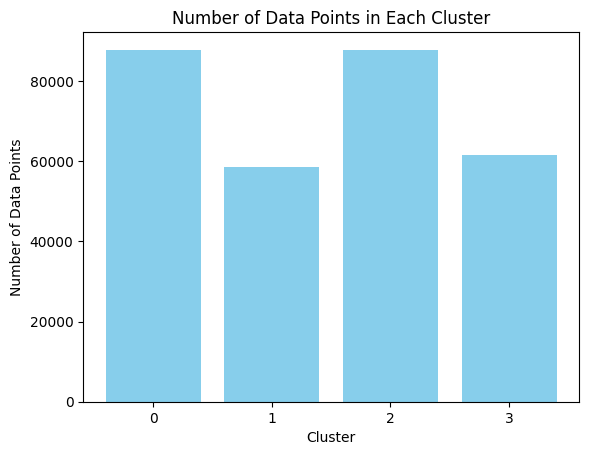

In [54]:
cluster_counts = df_cleaned['Clustered_Target'].value_counts()

# Plot a bar chart
plt.bar(cluster_counts.index, cluster_counts.values, color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.title('Number of Data Points in Each Cluster')
plt.xticks(cluster_counts.index)
plt.show()

# Add New Features

## Aggregations

In [55]:
columns = ['CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)',
           'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)',
           'R11 (MOhm)', 'R12 (MOhm)', 'R13 (MOhm)', 'R14 (MOhm)']
for col in columns:
    # Mean
    df_cleaned[f'{col} Mean'] = df_cleaned[col].rolling(window=100, min_periods=1).mean()
    # Median
    df_cleaned[f'{col}_Median'] = df_cleaned[col].rolling(window=100, min_periods=1).median()

    # Standard Deviation
    df_cleaned[f'{col}_Std'] = df_cleaned[col].rolling(window=100, min_periods=1).std()

## Rate of change

In [56]:
columns = ['Humidity (%r.h.)', 'Temperature (C)', 'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)',
           'R11 (MOhm)', 'R12 (MOhm)', 'R13 (MOhm)', 'R14 (MOhm)']
df_cleaned['CO_Rate_of_Change'] = df_cleaned['CO (ppm)'].diff() / df_cleaned['Time (s)'].diff()
for col in columns:
    df_cleaned[f'{col}_Rate_of_Change'] = df_cleaned[col].diff() / df_cleaned['Time (s)'].diff()

## Find correlations

/home/19jac16/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/19jac16/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


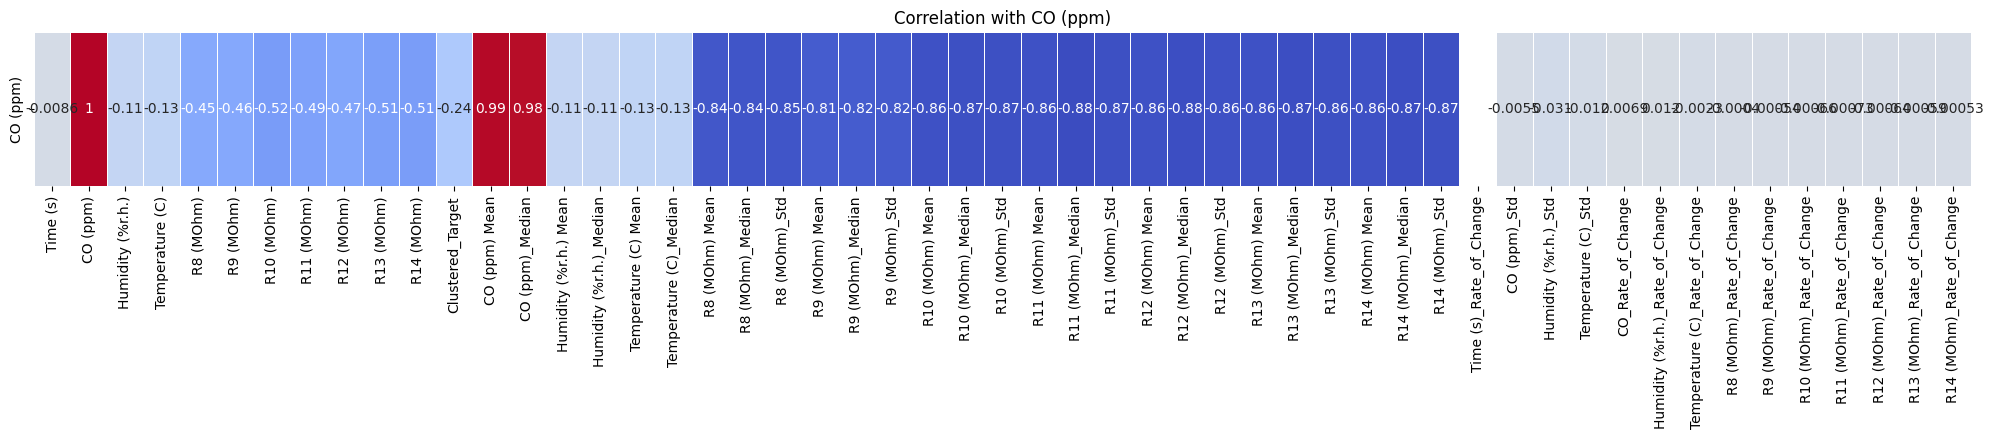

In [57]:
specific_column = 'CO (ppm)'

# Calculate correlation matrix for the specific column
column_correlation = df_cleaned.corrwith(df_cleaned[specific_column])

# Create a heatmap using Seaborn for visualization
plt.figure(figsize=(25, 2))
sns.heatmap(pd.DataFrame(column_correlation, columns=[specific_column]).T,
            annot=True, cmap='coolwarm', linewidths=.5, cbar=False)
plt.title(f'Correlation with {specific_column}')
plt.show()

# Remove columns with low correlation

In [58]:
absolute_correlation_threshold = 0.1  # Adjust as needed

# Calculate correlation with the specific column
column_correlation = df_cleaned.corr().abs()[specific_column]

# Find columns with correlation below the absolute threshold
low_correlation_cols = column_correlation[column_correlation < absolute_correlation_threshold].index

if 'Time (s)' in low_correlation_cols:
    low_correlation_cols = low_correlation_cols.drop('Time (s)')

# Drop columns with low correlation
df_filtered = df_cleaned.drop(low_correlation_cols, axis=1).fillna(method='bfill')

# Display the filtered DataFrame
print(df_filtered.columns)

Index(['Time (s)', 'CO (ppm)', 'Humidity (%r.h.)', 'Temperature (C)',
       'R8 (MOhm)', 'R9 (MOhm)', 'R10 (MOhm)', 'R11 (MOhm)', 'R12 (MOhm)',
       'R13 (MOhm)', 'R14 (MOhm)', 'Clustered_Target', 'CO (ppm) Mean',
       'CO (ppm)_Median', 'Humidity (%r.h.) Mean', 'Humidity (%r.h.)_Median',
       'Temperature (C) Mean', 'Temperature (C)_Median', 'R8 (MOhm) Mean',
       'R8 (MOhm)_Median', 'R8 (MOhm)_Std', 'R9 (MOhm) Mean',
       'R9 (MOhm)_Median', 'R9 (MOhm)_Std', 'R10 (MOhm) Mean',
       'R10 (MOhm)_Median', 'R10 (MOhm)_Std', 'R11 (MOhm) Mean',
       'R11 (MOhm)_Median', 'R11 (MOhm)_Std', 'R12 (MOhm) Mean',
       'R12 (MOhm)_Median', 'R12 (MOhm)_Std', 'R13 (MOhm) Mean',
       'R13 (MOhm)_Median', 'R13 (MOhm)_Std', 'R14 (MOhm) Mean',
       'R14 (MOhm)_Median', 'R14 (MOhm)_Std', 'Time (s)_Rate_of_Change'],
      dtype='object')


/tmp/ipykernel_1994983/1674936651.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filtered = df_cleaned.drop(low_correlation_cols, axis=1).fillna(method='bfill')


# Plot correlation

/home/19jac16/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/19jac16/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


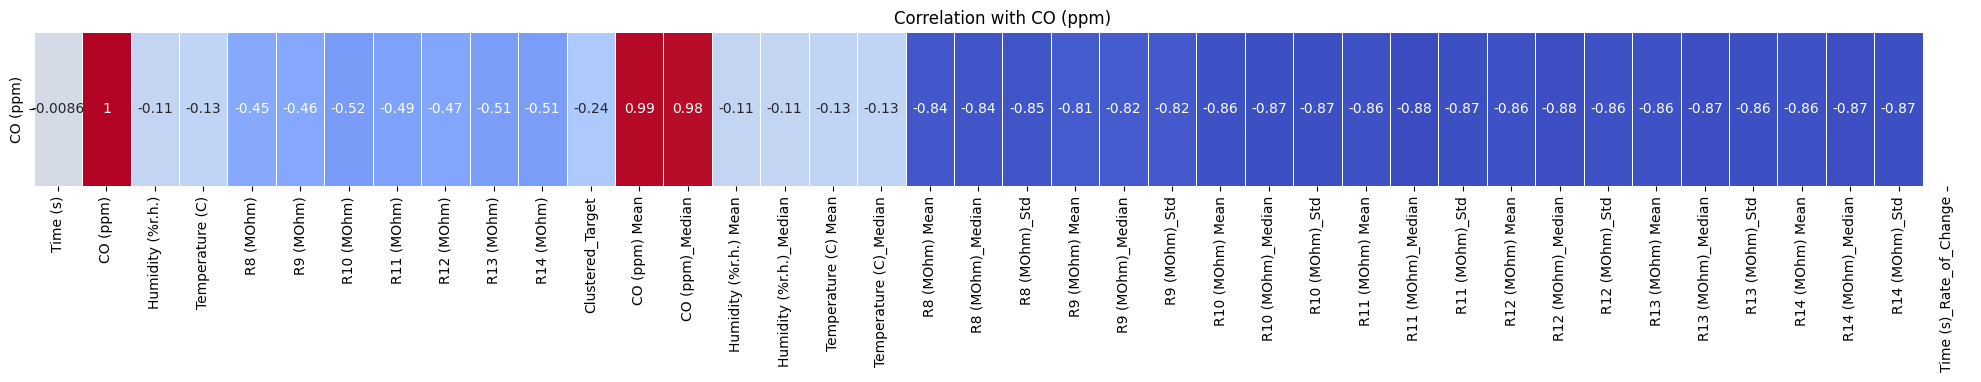

In [59]:
specific_column = 'CO (ppm)'

# Calculate correlation matrix for the specific column
column_correlation = df_filtered.corrwith(df_filtered[specific_column])

# Create a heatmap using Seaborn for visualization
plt.figure(figsize=(25, 2))
sns.heatmap(pd.DataFrame(column_correlation, columns=[specific_column]).T,
            annot=True, cmap='coolwarm', linewidths=.5, cbar=False)
plt.title(f'Correlation with {specific_column}')
plt.show()

In [60]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Selecting relevant features for the LSTM model
features = df_filtered.drop(columns=['CO (ppm)', 'Clustered_Target'])
target = df_filtered['CO (ppm)']

# Normalizing the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# Defining a function to create sequences for LSTM input
def create_sequences(input_data, target_data, sequence_length):
    sequences = []
    target = []
    for i in range(len(input_data) - sequence_length):
        sequences.append(input_data[i:i + sequence_length])
        target.append(target_data[i + sequence_length])
    return np.array(sequences), np.array(target)

# Sequence length for LSTM model (this can be tuned)
sequence_length = 30

# Creating sequences
X, y = create_sequences(scaled_features, target, sequence_length)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Checking the shape of the prepared data
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((236551, 30, 38), (59138, 30, 38), (236551,), (59138,))

## Batch Optimization

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define the LSTM model structure
def create_model():
    model = Sequential([
        LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(50, activation='relu'),
        Dense(1)  # Output layer for predicting CO concentration
    ])
    return model

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Batch sizes to test
batch_sizes = [8, 16, 32, 64, 128]

# Store histories for different batch sizes
histories = {}

for batch_size in batch_sizes:
    # Create a new model instance for each batch size
    lstm = create_model()

    # Compile the model
    lstm.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

    # Train the model
    history = lstm.fit(X_train, y_train, epochs=100, batch_size=batch_size, validation_split=0.1, callbacks=[early_stopping], verbose=1)

    # Store history
    histories[batch_size] = history

# Plotting the training loss for each batch size
plt.figure(figsize=(10, 6))
for batch_size in batch_sizes:
    plt.plot(histories[batch_size].history['loss'], label=f'Batch size {batch_size}')

plt.title('Training Loss for Different Batch Sizes')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.savefig('batch_optimization.png')
plt.show()

Epoch 1/100
  238/26612 [..............................] - ETA: 12:33 - loss: 37.3756

KeyboardInterrupt: 

## Layer Optimization

2023-12-14 19:32:57.193715: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-12-14 19:32:57.234281: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-14 19:32:57.878192: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-12-14 19:32:58.701817: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at htt

Epoch 1/100
2218/2218 [==============================] - 81s 35ms/step - loss: 5.4330 - val_loss: 1.0015
Epoch 2/100
2218/2218 [==============================] - 79s 35ms/step - loss: 1.9091 - val_loss: 0.9126
Epoch 3/100
2218/2218 [==============================] - 77s 35ms/step - loss: 1.4997 - val_loss: 0.7897
Epoch 4/100
2218/2218 [==============================] - 78s 35ms/step - loss: 1.1889 - val_loss: 0.4906
Epoch 5/100
2218/2218 [==============================] - 78s 35ms/step - loss: 0.9797 - val_loss: 0.6484
Epoch 6/100
2218/2218 [==============================] - 79s 35ms/step - loss: 0.8718 - val_loss: 0.4264
Epoch 7/100
2218/2218 [==============================] - 78s 35ms/step - loss: 0.6980 - val_loss: 0.3604
Epoch 8/100
2218/2218 [==============================] - 78s 35ms/step - loss: 0.6245 - val_loss: 0.4038
Epoch 9/100
2218/2218 [==============================] - 78s 35ms/step - loss: 0.5226 - val_loss: 0.3259
Epoch 10/100
2218/2218 [==============================]

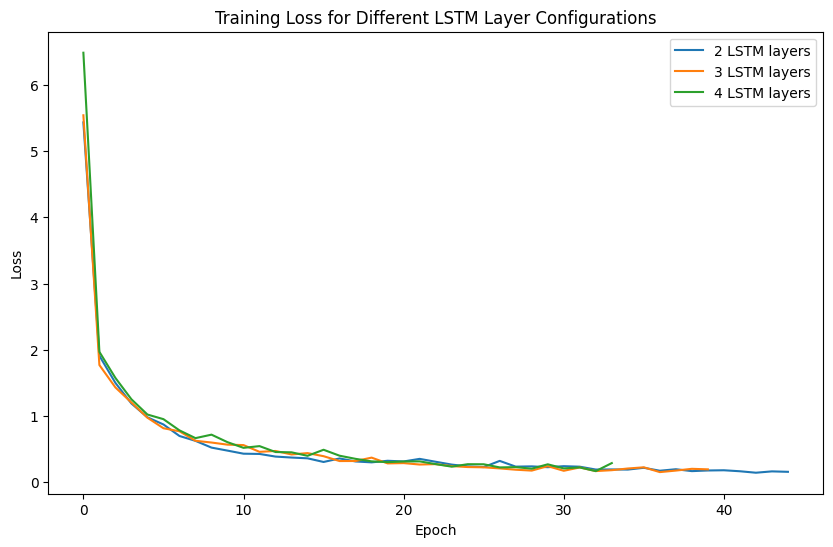

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Function to create LSTM model with a variable number of layers
def create_lstm_model(num_layers):
    model = Sequential()
    model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True if num_layers > 1 else False))
    model.add(Dropout(0.3))

    for _ in range(1, num_layers):
        model.add(LSTM(64, return_sequences=True if _ < num_layers - 1 else False))
        model.add(Dropout(0.3))

    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))  # Output layer

    return model

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Number of LSTM layers to test
layer_configs = [2, 3, 4]

# Store histories for different models
histories = {}

# Training each model
for num_layers in layer_configs:
    lstm = create_lstm_model(num_layers)
    lstm.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')
    history = lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stopping], verbose=1)
    histories[num_layers] = history

# Plotting the training loss for each model
plt.figure(figsize=(10, 6))
for num_layers in layer_configs:
    plt.plot(histories[num_layers].history['loss'], label=f'{num_layers} LSTM layers')

plt.title('Training Loss for Different LSTM Layer Configurations')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Normal LSTM

In [61]:
# Defining the LSTM model
lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)  # Output layer for predicting CO concentration
])

# Compiling the model
lstm.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks = [early_stopping], verbose=1)

# Evaluate the model on the test set
test_loss = lstm.evaluate(X_test, y_test)

Epoch 1/100
6653/6653 [==============================] - 238s 35ms/step - loss: 2.9618 - val_loss: 0.7947
Epoch 2/100
6653/6653 [==============================] - 233s 35ms/step - loss: 1.0780 - val_loss: 0.9965
Epoch 3/100
6653/6653 [==============================] - 233s 35ms/step - loss: 0.7569 - val_loss: 0.5770
Epoch 4/100
6653/6653 [==============================] - 235s 35ms/step - loss: 0.5764 - val_loss: 0.3613
Epoch 5/100
6653/6653 [==============================] - 235s 35ms/step - loss: 0.5174 - val_loss: 0.3368
Epoch 6/100
6653/6653 [==============================] - 232s 35ms/step - loss: 0.4010 - val_loss: 0.3164
Epoch 7/100
6653/6653 [==============================] - 233s 35ms/step - loss: 0.3627 - val_loss: 0.3080
Epoch 8/100
6653/6653 [==============================] - 233s 35ms/step - loss: 0.3056 - val_loss: 1.3819
Epoch 9/100
6653/6653 [==============================] - 233s 35ms/step - loss: 0.2891 - val_loss: 0.2480
Epoch 10/100
6653/6653 [======================

## BiDirectional LSTM

In [62]:
from tensorflow.keras.layers import Bidirectional

bidirectional_lstm = Sequential([
    Bidirectional(LSTM(50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(50, return_sequences=False),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

bidirectional_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = bidirectional_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks = [early_stopping], verbose=1)

Epoch 1/50
5914/5914 [==============================] - 226s 38ms/step - loss: 2.9719 - val_loss: 0.7718
Epoch 2/50
5914/5914 [==============================] - 220s 37ms/step - loss: 1.0179 - val_loss: 0.4208
Epoch 3/50
5914/5914 [==============================] - 220s 37ms/step - loss: 0.6096 - val_loss: 0.4208
Epoch 4/50
5914/5914 [==============================] - 221s 37ms/step - loss: 0.5132 - val_loss: 0.3981
Epoch 5/50
5914/5914 [==============================] - 221s 37ms/step - loss: 0.4016 - val_loss: 0.2836
Epoch 6/50
5914/5914 [==============================] - 220s 37ms/step - loss: 0.3502 - val_loss: 0.4479
Epoch 7/50
5914/5914 [==============================] - 220s 37ms/step - loss: 0.3042 - val_loss: 0.2874
Epoch 8/50
5914/5914 [==============================] - 220s 37ms/step - loss: 0.2732 - val_loss: 0.3080
Epoch 9/50
5914/5914 [==============================] - 219s 37ms/step - loss: 0.2729 - val_loss: 0.2220
Epoch 10/50
5914/5914 [==============================] 

## CNN+LSTM

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Define the model
cnn_lstm = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    LSTM(30, kernel_regularizer=l2(0.01)),  # L2 regularization
    Dropout(0.5),
    Dense(30, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

# Compiling the model
cnn_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001, verbose=1)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# Train the model
history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping, reduce_lr, model_checkpoint],
                       verbose=1)

# Load the best weights and evaluate on the test set
cnn_lstm.load_weights('best_model.h5')
test_loss = cnn_lstm.evaluate(X_test, y_test)


Epoch 1/100
5913/5914 [============================>.] - ETA: 0s - loss: 5.3103
Epoch 1: val_loss improved from inf to 1.65407, saving model to best_model.h5
5914/5914 [==============================] - 89s 15ms/step - loss: 5.3098 - val_loss: 1.6541 - lr: 0.0010
Epoch 2/100
5913/5914 [============================>.] - ETA: 0s - loss: 2.2344
Epoch 2: val_loss improved from 1.65407 to 1.51015, saving model to best_model.h5
5914/5914 [==============================] - 86s 15ms/step - loss: 2.2342 - val_loss: 1.5102 - lr: 0.0010
Epoch 3/100
5912/5914 [============================>.] - ETA: 0s - loss: 1.9256
Epoch 3: val_loss improved from 1.51015 to 1.37881, saving model to best_model.h5
5914/5914 [==============================] - 85s 14ms/step - loss: 1.9254 - val_loss: 1.3788 - lr: 0.0010
Epoch 4/100
5911/5914 [============================>.] - ETA: 0s - loss: 1.7830
Epoch 4: val_loss improved from 1.37881 to 1.15227, saving model to best_model.h5
5914/5914 [===========================

## GRU

In [65]:
from tensorflow.keras.layers import GRU
from tensorflow.keras.callbacks import EarlyStopping

# Defining the GRU model
gru = Sequential([
    GRU(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(50),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compiling the model
gru.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the model
history = gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks = [early_stopping], verbose=1)

Epoch 1/100
5914/5914 [==============================] - 218s 36ms/step - loss: 2.7002 - val_loss: 0.5107
Epoch 2/100
5914/5914 [==============================] - 211s 36ms/step - loss: 0.6249 - val_loss: 0.3083
Epoch 3/100
5914/5914 [==============================] - 208s 35ms/step - loss: 0.4404 - val_loss: 0.5410
Epoch 4/100
5914/5914 [==============================] - 204s 35ms/step - loss: 0.3538 - val_loss: 0.3371
Epoch 5/100
5914/5914 [==============================] - 203s 34ms/step - loss: 0.3037 - val_loss: 0.3315
Epoch 6/100
5914/5914 [==============================] - 205s 35ms/step - loss: 0.2726 - val_loss: 0.5109
Epoch 7/100
5914/5914 [==============================] - 202s 34ms/step - loss: 0.2596 - val_loss: 0.2963
Epoch 8/100
5914/5914 [==============================] - 199s 34ms/step - loss: 0.2197 - val_loss: 0.3687
Epoch 9/100
5914/5914 [==============================] - 201s 34ms/step - loss: 0.2003 - val_loss: 0.2711
Epoch 10/100
5914/5914 [======================

## Test Comparison

1849/1849 [==============================] - 18s 9ms/step


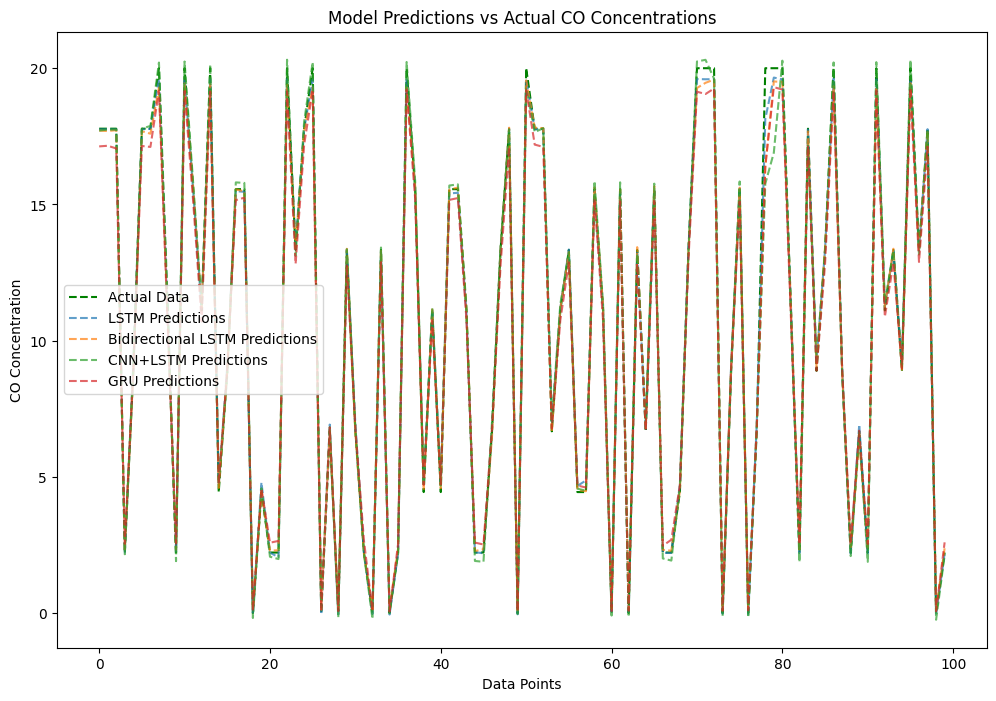

In [66]:
import matplotlib.pyplot as plt

# Generate predictions for each model
predictions_lstm = lstm.predict(X_test).flatten()
predictions_bidirectional_lstm = bidirectional_lstm.predict(X_test).flatten()
predictions_cnn_lstm = cnn_lstm.predict(X_test).flatten()
predictions_gru = gru.predict(X_test).flatten()
y_test_flattened = y_test.flatten()

# Number of data points to plot
num_points = 100

# Select a subset of data for plotting
subset_indices = slice(0, num_points)
actual_data_subset = y_test_flattened[subset_indices]
predictions_lstm_subset = predictions_lstm[subset_indices]
predictions_bidirectional_lstm_subset = predictions_bidirectional_lstm[subset_indices]
predictions_cnn_lstm_subset = predictions_cnn_lstm[subset_indices]
predictions_gru_subset = predictions_gru[subset_indices]

# Plotting
plt.figure(figsize=(12, 8))

# Plot actual data
plt.plot(actual_data_subset, label='Actual Data', color='green', linestyle='--')

# Plot model predictions
plt.plot(predictions_lstm_subset, label='LSTM Predictions', alpha=0.7, linestyle='--')
plt.plot(predictions_bidirectional_lstm_subset, label='Bidirectional LSTM Predictions', alpha=0.7, linestyle='--')
plt.plot(predictions_cnn_lstm_subset, label='CNN+LSTM Predictions', alpha=0.7, linestyle='--')
plt.plot(predictions_gru_subset, label='GRU Predictions', alpha=0.7, linestyle='--')

plt.title('Model Predictions vs Actual CO Concentrations')
plt.xlabel('Data Points')
plt.ylabel('CO Concentration')
plt.legend()

# Save the figure before showing it
plt.savefig('Predictions_comparison.png')

# Display the plot
plt.show()


 ## MSE Calculation

In [67]:
from sklearn.metrics import mean_squared_error

# Function to calculate MSE
def calculate_mse(model, X_test, y_test):
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    return mse
    

# LSTM Model
mse_lstm = calculate_mse(lstm, X_test, y_test)
print("LSTM MSE:", mse_lstm)

# Bidirectional LSTM Model
mse_bidirectional_lstm = calculate_mse(bidirectional_lstm, X_test, y_test) 
print("Bidirectional LSTM MSE:", mse_bidirectional_lstm)

# CNN+LSTM Model
mse_cnn_lstm = calculate_mse(cnn_lstm, X_test, y_test)
print("CNN+LSTM MSE:", mse_cnn_lstm)

# GRU Model
mse_gru = calculate_mse(gru, X_test, y_test)
print("GRU MSE:", mse_gru)

1849/1849 [==============================] - 22s 12ms/step
LSTM MSE: 0.11429585545753772
1849/1849 [==============================] - 21s 12ms/step
Bidirectional LSTM MSE: 0.14788085182451427
1849/1849 [==============================] - 9s 5ms/step
CNN+LSTM MSE: 0.7683590218525095
1849/1849 [==============================] - 18s 10ms/step
GRU MSE: 0.26856705396166347


## ARIMA and SARIMA

### 1. Check stationary

In [3]:
from statsmodels.tsa.arima.model import ARIMA

# Load a subset of the data for demonstration
file_path = 'dataset/20160930_203718.csv'
filtered_data = pd.read_csv(file_path)  # Using only the first 1000 rows
train_data = filtered_data[:295000]

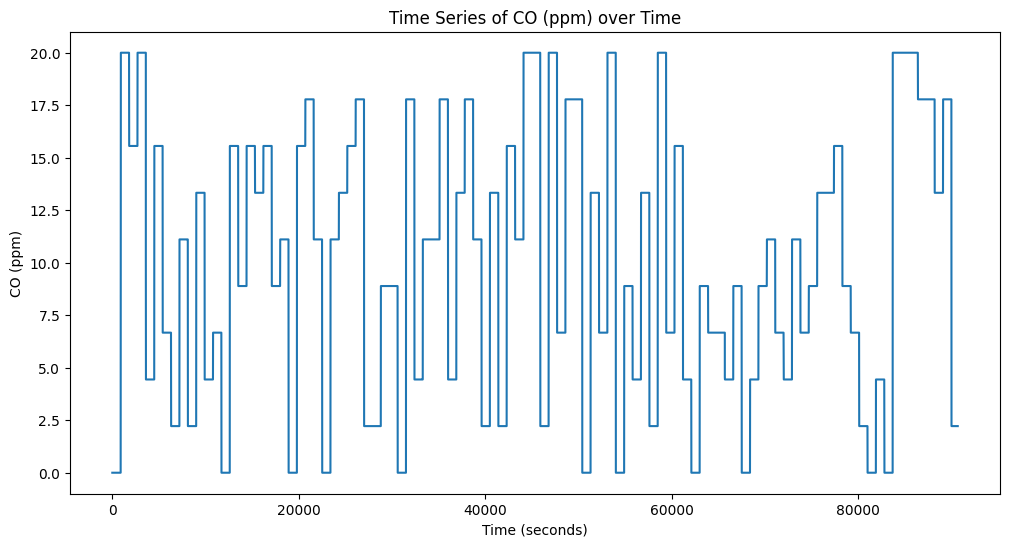

In [4]:
import matplotlib.pyplot as plt

# Plotting the time series data
plt.figure(figsize=(12, 6))
plt.plot(train_data['Time (s)'], train_data['CO (ppm)'])
plt.title('Time Series of CO (ppm) over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('CO (ppm)')
plt.show()

In [5]:
from statsmodels.tsa.stattools import adfuller

# Re-running the Augmented Dickey-Fuller test on the original data
adf_test_original = adfuller(train_data['CO (ppm)'])

# Extracting the result
adf_result_original = {
    'ADF Statistic': adf_test_original[0],
    'p-value': adf_test_original[1],
    'Number of Lags Used': adf_test_original[2],
    'Number of Observations Used': adf_test_original[3],
    'Critical Values': adf_test_original[4]
}

adf_result_original

{'ADF Statistic': -7.236129571203905,
 'p-value': 1.9374560453100143e-10,
 'Number of Lags Used': 43,
 'Number of Observations Used': 294956,
 'Critical Values': {'1%': -3.4303721706183667,
  '5%': -2.8615497991373466,
  '10%': -2.566775215725476}}

### 2. Find p and q

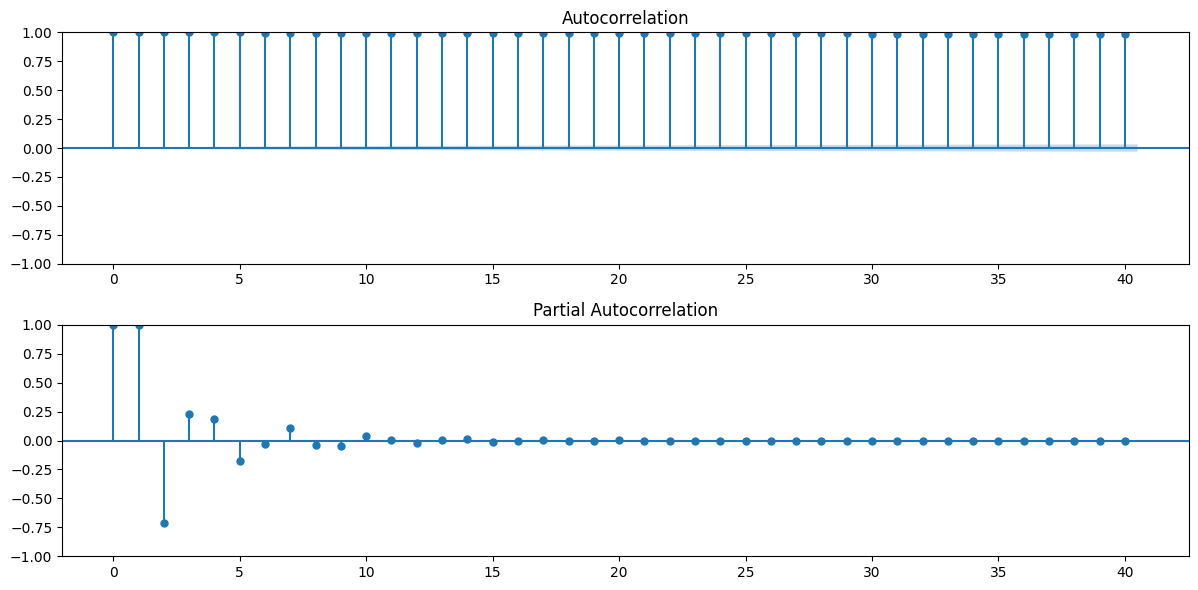

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting ACF and PACF
plt.figure(figsize=(12, 6))

# ACF plot
plt.subplot(211)
plot_acf(train_data['CO (ppm)'], ax=plt.gca(), lags=40)

# PACF plot
plt.subplot(212)
plot_pacf(train_data['CO (ppm)'], ax=plt.gca(), lags=40)

plt.tight_layout()
plt.show()

### 3. ARIMA

In [7]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppressing warnings for model convergence
warnings.filterwarnings("ignore")


# Starting with p=1 and q=1 as an initial guess
model = ARIMA(train_data['CO (ppm)'], order=(1, 1, 1))
model_fit = model.fit()

# Summary of the model
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               CO (ppm)   No. Observations:               295000
Model:                 ARIMA(1, 1, 1)   Log Likelihood              436563.372
Date:                Fri, 15 Dec 2023   AIC                        -873120.744
Time:                        22:54:31   BIC                        -873088.960
Sample:                             0   HQIC                       -873111.544
                             - 295000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6681   7.29e-05   9168.607      0.000       0.668       0.668
ma.L1          0.2828      0.000   2110.421      0.000       0.283       0.283
sigma2         0.0030   1.89e-07   1.61e+04      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                1426.77   Jarque-Bera (JB):      163507136691.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.47   Skew:                             5.90
Prob(H) (two-sided):                  0.00   Kurtosis:                      3650.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
# Starting with p=1 and q=1 as an initial guess
model = ARIMA(train_data['CO (ppm)'], order=(1, 1, 0))
model_fit = model.fit()

# Summary of the model
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               CO (ppm)   No. Observations:               295000
Model:                 ARIMA(1, 1, 0)   Log Likelihood              423189.108
Date:                Fri, 15 Dec 2023   AIC                        -846374.216
Time:                        22:54:47   BIC                        -846353.027
Sample:                             0   HQIC                       -846368.083
                             - 295000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7643   4.22e-05   1.81e+04      0.000       0.764       0.764
sigma2         0.0033   2.15e-07   1.55e+04      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):               24922.12   Jarque-Bera (JB):      135702322871.65
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.47   Skew:                             4.90
Prob(H) (two-sided):                  0.00   Kurtosis:                      3325.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 4. SARIMA

In [15]:
train_data.to_csv('dataset/co.csv', index=False)

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train_data['CO (ppm)'], order=(1, 1, 1), seasonal_order=(0, 0, 0, 24))
sarima_model_fit = sarima_model.fit(disp=False)

# Summary of the SARIMA model
sarima_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               CO (ppm)   No. Observations:               295000
Model:               SARIMAX(1, 1, 1)   Log Likelihood              436563.372
Date:                Fri, 15 Dec 2023   AIC                        -873120.744
Time:                        23:17:39   BIC                        -873088.960
Sample:                             0   HQIC                       -873111.544
                             - 295000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6681   7.29e-05   9168.607      0.000       0.668       0.668
ma.L1          0.2828      0.000   2110.421      0.000       0.283       0.283
sigma2         0.0030   1.89e-07   1.61e+04      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                1426.77   Jarque-Bera (JB):      163507136691.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.47   Skew:                             5.90
Prob(H) (two-sided):                  0.00   Kurtosis:                      3650.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""